# First Steps in Python: Markov Processes and Decisions

**30 minutes:** Python and probabilities (5 min), simulation (5 min), maze policy (10 min), cake eating (10 min).

In Colab, save a copy in Drive and connect to a CPU runtime. Run cells from top to bottom with **Shift+Enter**. Complete the two coding exercises; double-click each solution block to reveal its code.

[Lecture slides](https://yaolangzhong.github.io/U_Tokyo_Comp_Econ_Course/downloads/week_01/lecture/Introduction_to_Markov_Decision_Processes.pdf)

## 1. States and probabilities · 5 min

A **variable** names a value; `=` assigns it. A **list** stores values in order, starting at index `0`. `import` loads a package; **NumPy** supplies numerical arrays. `#` starts a comment, and `print(...)` displays a result.

The states are unemployed (`U`) and employed (`E`). An unemployed worker finds a job with probability $\alpha=0.20$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

states = ["Unemployed", "Employed"]   # A Python list
current_state = 0
alpha = 0.20
p_unemployed = np.array([1 - alpha, alpha])

print("Current state:", states[current_state])
print("Next-state probabilities [U, E]:", p_unemployed)
print("Sum:", p_unemployed.sum())

Current state: Unemployed
Next-state probabilities [U, E]: [0.8 0.2]
Sum: 1.0


An employed worker loses their job with probability $\delta=0.05$. In the transition matrix `P`, **rows are today's state and columns are tomorrow's**, ordered `[U, E]`.

`mu0` describes probabilities over states, not one worker's realized state. The next distribution is $\mu_1=\mu_0P$: `@` means matrix multiplication. `assert` checks a condition; `np.allclose` allows small rounding differences.

In [2]:
delta = 0.05
P = np.array([[1 - alpha, alpha],
              [delta, 1 - delta]])
mu0 = np.array([0.60, 0.40])
mu1 = mu0 @ P

print("P:", P, sep="\n")
print("U to E probability:", P[0, 1])
print("Next distribution:", mu1)       # [0.50, 0.50]
assert np.all(P >= 0)
assert np.allclose(P.sum(axis=1), 1)   # Each row sums to one

P:
[[0.8  0.2 ]
 [0.05 0.95]]
U to E probability: 0.2
Next distribution: [0.5 0.5]


## 2. A Markov-process class · 5 min

A **class** groups data and functions. `__init__` sets up an object; `self.P` stores its matrix. A function inside a class is a **method**, defined with `def`.

`simulate` draws a path: `for` repeats, `.append` records a state, and `return` sends back the result. Indentation groups instructions. A fixed **seed** makes the random draws repeatable.

In [3]:
class MarkovProcess:
    def __init__(self, states, P):
        self.states = states
        self.P = np.array(P)
        assert self.P.shape == (len(states), len(states))
        assert np.all(self.P >= 0)
        assert np.allclose(self.P.sum(axis=1), 1)

    def simulate(self, initial_state, periods, seed=7):
        rng = np.random.default_rng(seed)
        state = initial_state
        path = [state]
        for period in range(periods):
            state = rng.choice(len(self.states), p=self.P[state])
            path.append(state)
        return np.array(path)

Simulated states: [0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0]


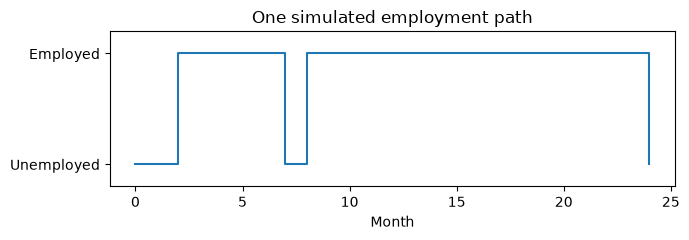

In [4]:
employment = MarkovProcess(states, P)
path = employment.simulate(initial_state=0, periods=24, seed=7)
print("Simulated states:", path)

plt.figure(figsize=(7, 2.5))
plt.step(range(len(path)), path, where="post")
plt.yticks([0, 1], states)
plt.xlabel("Month")
plt.title("One simulated employment path")
plt.ylim(-0.2, 1.2)
plt.tight_layout()
plt.show()

## 3. Exercise 1: Maze policy · 10 min

The state vector `[row, column]` is a location, not a probability vector. A **policy** takes a state and returns an action.

```text
.  .  G       Start [2, 0]; goal [0, 2]; wall [1, 1]
.  #  .       Actions: up, down, left, right
S  .  .
```

A wall or boundary blocks movement. Each move from outside the goal earns `-1`, including entry into the goal; at the goal, the state stays fixed and reward is `0`.

**Run the supplied class.** `step` returns the next state and reward; `simulate` calls the policy each period. `moves` is a **dictionary** mapping action names to displacement vectors.

In [5]:
class MazeMDP:
    def __init__(self):
        self.goal = np.array([0, 2])
        self.wall = np.array([1, 1])
        self.beta = 0.95
        self.moves = {
            "up": np.array([-1, 0]),
            "down": np.array([1, 0]),
            "left": np.array([0, -1]),
            "right": np.array([0, 1])
        }

    def step(self, state, action):
        if np.array_equal(state, self.goal):
            return state.copy(), 0
        next_state = state + self.moves[action]
        inside = np.all(next_state >= 0) and np.all(next_state < 3)
        if not inside or np.array_equal(next_state, self.wall):
            next_state = state.copy()
        return next_state, -1

    def simulate(self, policy, initial_state, periods):
        state = np.array(initial_state)
        path = [state.copy()]
        rewards = []
        for period in range(periods):
            action = policy(state)
            state, reward = self.step(state, action)
            path.append(state.copy())
            rewards.append(reward)
        return np.array(path), np.array(rewards)

This supplied policy goes up first, then right. `if` / `else` selects an action. Pass the function to `simulate` without parentheses so it can be called at each state.

In [6]:
def up_then_right(state):
    if state[0] > 0:
        return "up"
    else:
        return "right"

maze = MazeMDP()
maze_path, rewards = maze.simulate(up_then_right, [2, 0], periods=6)
print("Locations:", maze_path, sep="\n")
print("Rewards:", rewards)

Locations:
[[2 0]
 [1 0]
 [0 0]
 [0 1]
 [0 2]
 [0 2]
 [0 2]]
Rewards: [-1 -1 -1 -1  0  0]


**Your code:** write `right_then_up(state)` to move right to column 2, then up. Simulate six periods from `[2, 0]`; print the path and rewards. Check that it reaches the goal after four moves and remains there.

Replace `pass` (a placeholder that does nothing), then uncomment the checks.

In [7]:
def right_then_up(state):
    pass

# path, rewards = maze.simulate(right_then_up, [2, 0], periods=6)
# print(path)
# print(rewards)
# assert np.array_equal(path[4:], [[0, 2], [0, 2], [0, 2]])
# assert np.array_equal(rewards, [-1, -1, -1, -1, 0, 0])

In [8]:
#@title Solution 1: Maze policy (double-click to show code)
#@markdown The code is hidden. Double-click to reveal it; run the cell to define `maze_solution()`, then call that function in a new cell to check the solution.
def maze_solution():
    # Keep this reference policy separate from your exercise code.
    def right_then_up(state):
        if state[1] < 2:
            return "right"
        else:
            return "up"

    maze = MazeMDP()
    path, rewards = maze.simulate(right_then_up, [2, 0], periods=6)
    print("Locations:", path, sep="\n")
    print("Rewards:", rewards)
    assert np.array_equal(path, [[2, 0], [2, 1], [2, 2], [1, 2],
                                 [0, 2], [0, 2], [0, 2]])
    assert np.array_equal(rewards, [-1, -1, -1, -1, 0, 0])
    next_state, reward = maze.step(np.array([1, 0]), "right")
    assert np.array_equal(next_state, [1, 0]) and reward == -1
    return path, rewards


## 4. Exercise 2: Cake eating · 10 min

Use whole units of cake: state $k\in\{0,1,2,3,4\}$, consumption $c\in\{0,\ldots,k\}$.

- Next state: $k'=k-c$.
- Reward: $\sqrt{c}$, written `np.sqrt(action)`.
- At zero cake, consume zero and stay at zero.

**Your code:** complete `step` and `consume_one`; the simulation loop is supplied. In `step`, check `0 <= action <= state` and return the next stock and reward. The policy consumes one unit when cake remains and zero otherwise. Use whole-number actions throughout.

In [9]:
class CakeMDP:
    def __init__(self):
        self.beta = 0.95

    def step(self, state, action):
        # Check feasibility, then return next stock and reward.
        pass

    def simulate(self, policy, initial_state, periods):
        state = initial_state
        path, rewards = [state], []
        for period in range(periods):
            action = policy(state)
            state, reward = self.step(state, action)
            path.append(state)
            rewards.append(reward)
        return np.array(path), np.array(rewards)


def consume_one(state):
    # Consume one unit if state > 0; otherwise consume zero.
    pass

Uncomment and run these checks after completing your code. Five periods give six states, including the initial stock.

In [10]:
# cake = CakeMDP()
# cake_path, cake_rewards = cake.simulate(consume_one, 4, periods=5)
# print("Cake remaining:", cake_path)
# print("Rewards:", cake_rewards)
# assert np.array_equal(cake_path, [4, 3, 2, 1, 0, 0])
# assert np.allclose(cake_rewards, [1, 1, 1, 1, 0])
# stock, reward = cake.step(4, 2)
# assert stock == 2 and np.isclose(reward, np.sqrt(2))

In [11]:
#@title Solution 2: Cake eating (double-click to show code)
#@markdown The code is hidden. Double-click to reveal it; run the cell to define `cake_solution()`, then call that function in a new cell to check the solution.
def cake_solution():
    # These local definitions leave your CakeMDP and policies unchanged.
    class CakeMDP:
        def __init__(self):
            self.beta = 0.95

        def step(self, state, action):
            assert isinstance(state, (int, np.integer)) and 0 <= state <= 4
            assert isinstance(action, (int, np.integer)) and 0 <= action <= state
            return state - action, np.sqrt(action)

        def simulate(self, policy, initial_state, periods):
            state = initial_state
            path = [state]
            rewards = []
            for period in range(periods):
                action = policy(state)
                state, reward = self.step(state, action)
                path.append(state)
                rewards.append(reward)
            return np.array(path), np.array(rewards)

    def consume_one(state):
        return min(1, state)

    cake = CakeMDP()
    path_one, rewards_one = cake.simulate(consume_one, 4, periods=5)
    print("Consume one: stocks", path_one, "rewards", rewards_one)
    assert np.array_equal(path_one, [4, 3, 2, 1, 0, 0])
    assert np.allclose(rewards_one, [1, 1, 1, 1, 0])
    next_stock, reward = cake.step(4, 2)
    assert next_stock == 2 and np.isclose(reward, np.sqrt(2))
    next_stock, reward = cake.step(0, 0)
    assert next_stock == 0 and reward == 0
    return cake, path_one, rewards_one


## Save your work

After completing both exercises, restart the runtime and run all cells. Save and download your `.ipynb` file. The companion `markov_processes.py` contains the same code; solution functions run only when called.

**Further reading:** [Python tutorial](https://docs.python.org/3/tutorial/) · [NumPy basics](https://numpy.org/doc/stable/user/absolute_beginners.html).